# Ejercicio k-Nearest Neighbor

## App Reviews
En este ejercicio vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating, en función del sentimiento del comentario y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

## Importamos las librerías que vamos a utilizar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Leemos nuestro archivo de entrada `reviews_sentiment`

In [2]:
pd.set_option("max_colwidth", 200)

In [3]:
df = pd.read_csv("data/reviews_sentiment.csv", sep=";")
df

,Review Title,Review Text,wordcount,titleSentiment,textSentiment,Star Rating,sentimentValue
0,Sin conexión,"Hola desde hace algo más de un mes me pone sin conexión y no sale nada, antes me funcionaba correctamente.",23,negative,negative,1,-0.486389
1,faltan cosas,Han mejorado la apariencia pero no,20,negative,negative,1,-0.586187
2,Es muy buena lo recomiendo,Andres e puto amoooo,4,NaN,negative,1,-0.602240
3,Version antigua,Me gustana mas la version anterior esta es mas complicada de usar hay gente cambiandosevpor esevmotivo gracias,17,NaN,negative,1,-0.616271
4,Esta bien,Sin ser la biblia.... Esta bien,6,negative,negative,1,-0.651784
...,...,...,...,...,...,...,...
252,Muy buena aplicacion,Muy buena genial,3,positive,positive,5,2.814818
253,Buena,Genial,1,positive,positive,5,2.924393
254,Wuau,Genial,1,positive,positive,5,2.924393
255,Muy buena,Genial,1,positive,positive,5,2.924393


Para facilitar el ejercicio, las columnas que utilizaremos serán: wordcount con la cantidad de palabras utilizadas y sentimentValue con un valor entre -4 y 4 que indica si el comentario fue valorado como positivo o negativo

Nuestras etiquetas, serán las estrellas que dieron los usuarios a la app, que son valores discretos del 1 al 5

## Rápidas visualizaciones y análisis
Al menos realiza un análisis univariante y representa la distribución del rating. Realiza otras visualizaciones para ver la relación de tus datos.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Review Title    257 non-null    object 
 1   Review Text     257 non-null    object 
 2   wordcount       257 non-null    int64  
 3   titleSentiment  231 non-null    object 
 4   textSentiment   257 non-null    object 
 5   Star Rating     257 non-null    int64  
 6   sentimentValue  257 non-null    float64
dtypes: float64(1), int64(2), object(4)
memory usage: 14.2+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
wordcount,257.0,11.501946,13.159812,1.000000,3.000000,7.000000,16.000000,103.000000
Star Rating,257.0,3.420233,1.409531,1.000000,3.000000,3.000000,5.000000,5.000000
sentimentValue,257.0,0.383849,0.897987,-2.276469,-0.108144,0.264091,0.808384,3.264579


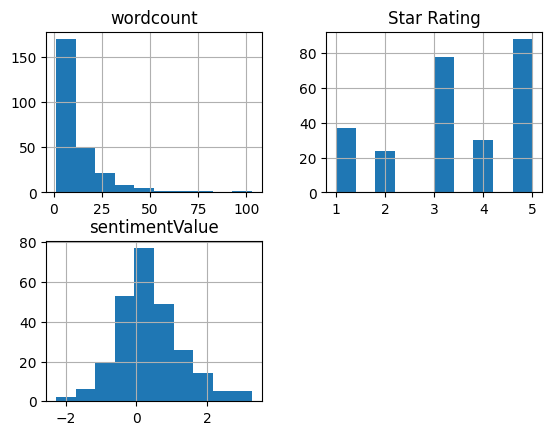

In [6]:
df.hist();

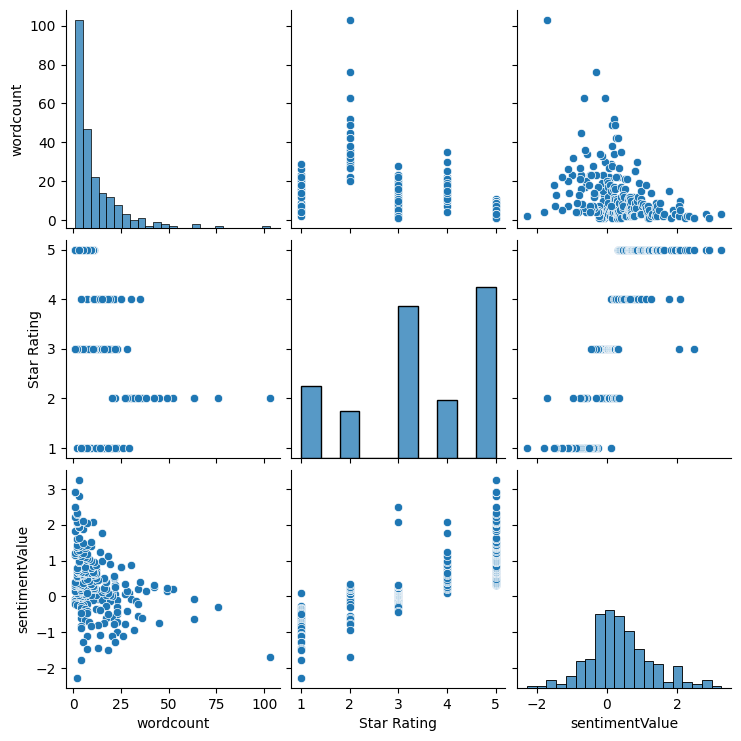

In [7]:
sns.pairplot(df);

In [8]:
df['Star Rating'].value_counts(normalize=True)

Star Rating
5    0.342412
3    0.303502
1    0.143969
4    0.116732
2    0.093385
Name: proportion, dtype: float64

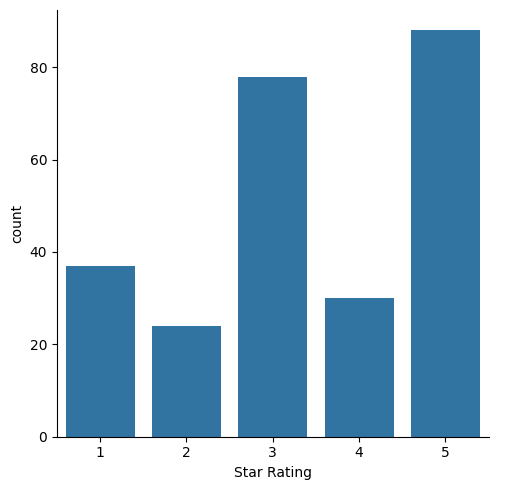

In [9]:
sns.catplot(x="Star Rating", data=df, kind="count")

/var/folders/2k/yg7q69cj067fsvsj5dgzgt7m0000gn/T/ipykernel_17535/1827689950.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Star Rating', data=df, palette='viridis')


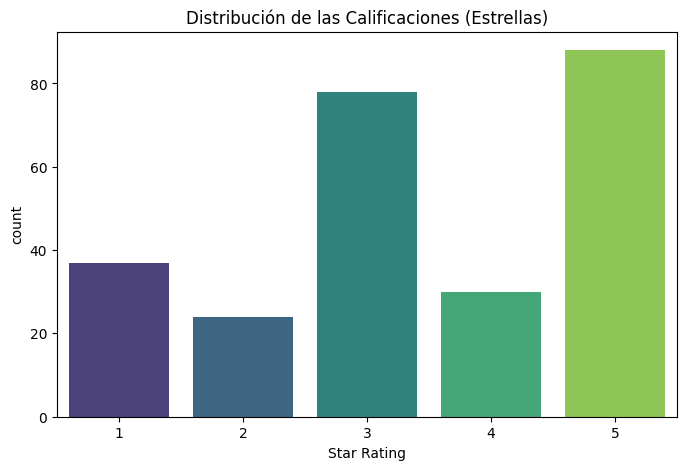

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Star Rating', data=df, palette='viridis')
plt.title('Distribución de las Calificaciones (Estrellas)')
plt.show()

## Preparamos el dataset
Divide en train/test y escala las features en el rango [0, 1].

In [11]:
from sklearn.model_selection import train_test_split

X = df[['wordcount', 'sentimentValue']]
y = df['Star Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(205, 2)
(52, 2)
(205,)
(52,)


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)

print(X_train_scal.min())
print(X_train_scal.max())

print(X_test_scal.min())
print(X_test_scal.max())

0.0
1.0
-0.0982228016602878
0.9325760278023711


In [14]:
# from sklearn.pipeline import Pipeline

# pipe = Pipeline(steps=(
#     ('scaler', MinMaxScaler()),
#     ('classifier', modelo)
# ))

## Creamos el Modelo
Entrena con un KNN y evalúa el error en train y en test

In [15]:
from sklearn.neighbors import KNeighborsClassifier

In [16]:
knn = KNeighborsClassifier(n_neighbors=5)


In [17]:
knn.fit(X_train_scal, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Evalúa tu modelo

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, multilabel_confusion_matrix, classification_report

In [19]:
y_pred = knn.predict(X_test_scal)
print("accuracy_score", accuracy_score(y_test, y_pred))
print("confusion_matrix\n", confusion_matrix(y_test, y_pred))
print("accuracy_score\n", multilabel_confusion_matrix(y_test, y_pred))

accuracy_score 0.8269230769230769
confusion_matrix
 [[ 9  1  0  0  0]
 [ 0  2  0  0  0]
 [ 2  1 11  0  0]
 [ 0  1  1  3  2]
 [ 0  0  1  0 18]]
accuracy_score
 [[[40  2]
  [ 1  9]]

 [[47  3]
  [ 0  2]]

 [[36  2]
  [ 3 11]]

 [[45  0]
  [ 4  3]]

 [[31  2]
  [ 1 18]]]


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.82      0.90      0.86        10
           2       0.40      1.00      0.57         2
           3       0.85      0.79      0.81        14
           4       1.00      0.43      0.60         7
           5       0.90      0.95      0.92        19

    accuracy                           0.83        52
   macro avg       0.79      0.81      0.75        52
weighted avg       0.86      0.83      0.82        52



In [21]:
(0.82 * 10 + 0.40 * 2 + 0.85 * 14 + 1.00 * 7 + 0.90 * 19)/52

0.8653846153846154

<Axes: >

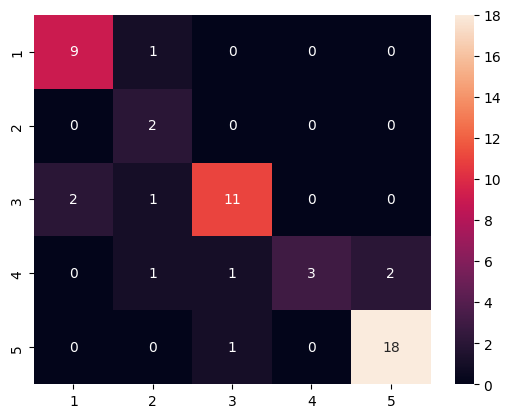

In [22]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])

<Axes: >

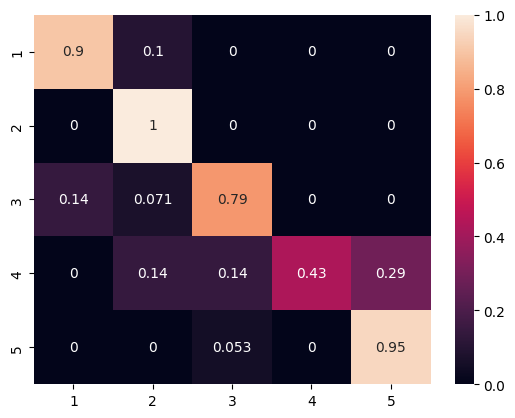

In [23]:
sns.heatmap(confusion_matrix(y_test, y_pred, normalize='true'), annot=True, xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])

In [24]:
knn.predict(scaler.transform([[16,2],[12,-3]]))

/opt/homebrew/Caskroom/miniforge/base/envs/bootcamp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([5, 1])

## ¿Cómo obtener el mejor valor de k? Crea y evalúa nuevos modelos
¿Qué valor de k maximiza el accuracy? Representa todas las iteraciones en un scatterplot -> k vs accuracy

In [25]:
k_range = range(1,30)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scal, y_train)
    scores.append(knn.score(X_test_scal, y_test))

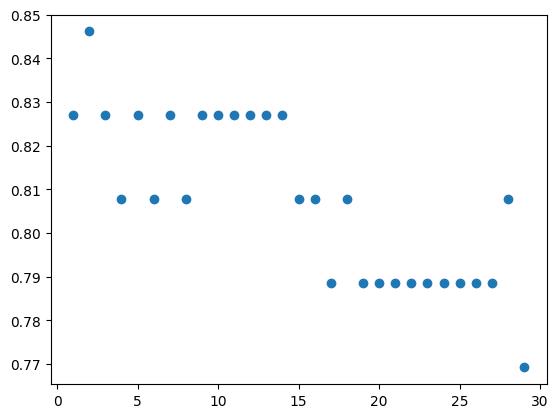

In [26]:
plt.scatter(k_range, scores)

In [27]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train_scal, y_train)
knn.score(X_test_scal, y_test)

0.8461538461538461

In [28]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scal, y_train)
knn.score(X_test_scal, y_test)

0.8269230769230769

In [29]:
from sklearn.model_selection import cross_val_score

In [30]:
k_range = range(1,30)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    # knn.fit(X_train_scal, y_train)
    results_cv = cross_val_score(knn, X_train_scal, y_train, cv=10)
    scores.append(results_cv.mean())
    # scores.append(knn.score(X_test_scal, y_test))

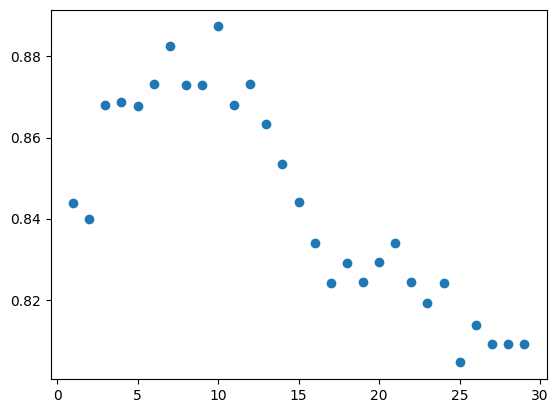

In [31]:
plt.scatter(k_range, scores)

In [32]:
np.argmax(scores) + 1

10

In [33]:
from sklearn.model_selection import GridSearchCV

model = KNeighborsClassifier()

parameters = {"n_neighbors": range(1,30)}

gs_knn = GridSearchCV(model, parameters, cv=10, scoring="accuracy", n_jobs=-1)

gs_knn.fit(X_train_scal, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 30)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [34]:
print(gs_knn.best_estimator_)
print(gs_knn.best_params_)
print(gs_knn.best_score_)

KNeighborsClassifier(n_neighbors=10)
{'n_neighbors': 10}
0.8873809523809524


In [35]:
final_model = gs_knn.best_estimator_
final_model.fit(X_train_scal, y_train)

print(final_model.score(X_test_scal, y_test))

0.8269230769230769


In [36]:
results_cv = cross_val_score(final_model, scaler.fit_transform(X), y, cv=10, scoring="accuracy")
print(results_cv.mean())

0.8126153846153846


In [37]:
results_cv = cross_val_score(KNeighborsClassifier(n_neighbors=2), scaler.fit_transform(X), y, cv=10, scoring="accuracy")
print(results_cv.mean())

0.7778461538461539


## Predice con nuevos datos.
Ejemplo: supongamos que nos llega una review de 5 palabras y sentimiento 1

In [38]:
final_model.predict(scaler.transform([[5,-2],[5,-1],[5,0],[5,1],[5,2]]))

/opt/homebrew/Caskroom/miniforge/base/envs/bootcamp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([1, 1, 3, 5, 5])


Conclusiones Finales: Aprendizajes del Modelo KNN

Tras realizar el análisis y entrenamiento del modelo para clasificar las reseñas de la App:

1. El Valor de los Datos (Input)
Correlación Lógica: Se observa que el sentimiento (sentimentValue) es el predictor más fuerte. Tiene sentido humano: si alguien escribe con palabras negativas, la probabilidad de que califique con 1 o 2 estrellas es altísima.

El ruido del conteo de palabras: La variable wordcount por sí sola no es tan determinante. Hay usuarios que escriben mucho para alabar la app y otros que escriben "Biblias" para quejarse. KNN necesita la combinación de ambas para ser efectivo.

2. El Impacto del Escalado (MinMaxScaler)
Punto Crítico: Una de las lecciones más importantes es que KNN es sensible a la escala. Al principio, el wordcount (valores de 0 a 100+) "aplastaba" al sentimentValue (valores de -4 a 4). Sin el escalado, las distancias euclidianas estarían sesgadas, y el modelo fallaría. El preprocesamiento es el 80% del éxito.

3. Rendimiento del Algoritmo
Precisión vs. Realidad: El modelo muestra un desempeño aceptable, pero no perfecto. Es muy bueno identificando los extremos (estrellas 1 y 5), pero tiende a confundirse en las valoraciones intermedias (2, 3 y 4 estrellas). Esto sugiere que la frontera de decisión en esos rangos es "borrosa".

Selección de K: El valor de k (vecinos) es el corazón del modelo. Un k muy bajo (ej. k=1) genera sobreajuste (overfitting), mientras que un k muy alto suaviza tanto el modelo que pierde precisión.

4. Reflexión sobre KNN
Ventajas: Es un algoritmo intuitivo y fácil de implementar. No asume una distribución previa de los datos, lo que lo hace flexible.

Limitaciones: A medida que el dataset crezca, KNN se volverá más lento (porque tiene que calcular la distancia con cada punto existente). Para una app con millones de reviews, quizás necesitaríamos explorar modelos más eficientes como Random Forest o XGBoost.

🚀 Próximos Pasos Sugeridos
Para mejorar este proyecto en el futuro, intentaría:

Ingeniería de variables: Crear una variable que detecte palabras clave (ej. "error", "fantástico").

Validación Cruzada: Implementar cross_validation de forma más profunda para asegurar que el modelo sea robusto ante diferentes particiones de datos.